# Lab Assignment 2 - Part A: Linear Regression
Please refer to the `README.pdf` for full laboratory instructions.

## Problem Statement
A dataset is included related to red and white vinho verde wine samples, from the north of Portugal. In this exercise, we look at a subset of the data and try to **predict wine's citric acid level based on other features**.

### Dataset Description
Input variables (based on physicochemical tests):
1. fixed acidity
2. volatile acidity
3. **citric acid** (TARGET - what we want to predict)
4. residual sugar
5. chlorides
6. free sulfur dioxide
7. total sulfur dioxide
8. density
9. pH
10. sulphates
11. alcohol
12. quality (score between 0 and 10)

### Your Tasks
1. **Implement linear regression** from scratch using least-squares (you may use `np.linalg.lstsq()`)
2. Start with 'alcohol' and 'density' as features. **Find a 3rd feature** that improves prediction the most
3. **Find the 4th feature**. Analyze what happens with all features
4. **Provide plots** comparing predictions vs actual values

## Setup: Load the Dataset
The data is provided through `ucimlrepo`. Install and import required packages below.

In [17]:
!pip install ucimlrepo

In [18]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
# We take 100 samples and predict the citric acid number through various features
X = wine_quality.data.features[:100]
X = X.drop(columns=['citric_acid'])
y = wine_quality.data.features[:100]['citric_acid']
print(X.keys())

Index(['fixed_acidity', 'volatile_acidity', 'residual_sugar', 'chlorides',
       'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH',
       'sulphates', 'alcohol'],
      dtype='object')


### Write and Run Your Own Code

In [19]:
#Library declarations
import matplotlib.pyplot as plt
import numpy as np

In [20]:
# Task 1: Implement Linear Regression
# Hint: You can use np.linalg.lstsq() or implement the normal equation: w = (X^T X)^{-1} X^T y

def linear_regression(X, y):
    """
    Implement linear regression using least-squares.
    
    Parameters:
    -----------
    X : numpy array of shape (n_samples, n_features)
    y : numpy array of shape (n_samples,)
    
    Returns:
    --------
    coefficients : numpy array
    """
    # TODO: Implement this function
    
    n_samples = X.shape[0] # extracting the number of samples 

    # Add bias (intercept) column
    X_bias = np.hstack((np.ones((n_samples, 1)), X))

    # Solve least squares problem
    coefficients, _, _, _ = np.linalg.lstsq(X_bias, y, rcond=None)
    return coefficients
    # pass


def compute_error(X, y, coefficients):
    """
    Compute the prediction error.
    
    Returns:
    --------
    error : float (e.g., RMSE or L2 norm)
    """
    # TODO: Implement this function
    
    n_samples = X.shape[0]

    # Add bias column
    X_bias = np.hstack((np.ones((n_samples, 1)), X))

    # Predictions using matrix multiplication with bias and the weights (coefficients)
    y_pred = X_bias @ coefficients

    #using RMSE to find the error
    error = np.sqrt(np.mean((y_pred - y) ** 2))
    return error 
    # pass


## Task 2: Start with Two Features
Use 'alcohol' and 'density' as initial features. Train your model and compute the error.

In [21]:
# Create feature matrix with 'alcohol' and 'density'
X_2features = np.vstack((X['alcohol'], X['density'])).T

# TODO: Train model and compute error
model_2 = linear_regression(X_2features, y)
error_2 = compute_error(X_2features, y, model_2)
print(f"Error with 2 features: {error_2:.4f}")


Error with 2 features: 0.1686


## Task 3: Find the 3rd Feature
Try adding each remaining feature one at a time. Which one improves the model the most?

**Hint**: You might want to look at correlations between features.


In [22]:
# TODO: Try each remaining feature and find the best 3rd feature
min_error = float("inf")
for key in X.keys():
    if key not in ['alcohol', 'density']:
        X_new = np.vstack((X['alcohol'], X['density'], X[key])).T
        # Train model and compute error
        # Print results
        model = linear_regression(X_new, y)
        error = compute_error(X_new, y, model)
        print(f"Error with 3 features: {error:.4f}")
        if error < min_error:
            min_error = error
            best_key = key 
            
print(f"The best third key is {best_key} with an error of {min_error}")
# Creating variables to store the model for the best three features
X_3features = np.vstack((X['alcohol'], X['density'],X[best_key])).T
model_3 = linear_regression(X_3features, y)
error_3 = compute_error(X_3features, y, model_3)

Error with 3 features: 0.1538
Error with 3 features: 0.1320
Error with 3 features: 0.1634
Error with 3 features: 0.1637
Error with 3 features: 0.1675
Error with 3 features: 0.1618
Error with 3 features: 0.1605
Error with 3 features: 0.1630
The best third key is volatile_acidity with an error of 0.13203983518141008


## Task 4: Find the 4th Feature and Full Model
Continue the analysis. What is the best 4th feature? What happens when you use all features?


In [23]:
# TODO: Find the best 4th feature

min_error = float("inf")
for key in X.keys():
    if key not in ['alcohol', 'density','volatile_acidity']:
        X_new = np.vstack((X['alcohol'], X['density'], X['volatile_acidity'],X[key])).T
        # Train model and compute error
        # Print results
        model = linear_regression(X_new, y)
        error = compute_error(X_new, y, model)
        print(f"Error with 4 features: {error:.4f}")
        if error < min_error:
            min_error = error
            best_key = key 
            
print(f"The best fourth key is {best_key} with an error of {min_error}")



# TODO: Train full model with all features
X_all = np.vstack([X[key] for key in X.keys()]).T
model_full = linear_regression(X_all, y)
error = compute_error(X_all, y, model_full)
print(f"Error with all features: {error:.4f}")




Error with 4 features: 0.1242
Error with 4 features: 0.1295
Error with 4 features: 0.1258
Error with 4 features: 0.1307
Error with 4 features: 0.1258
Error with 4 features: 0.1283
Error with 4 features: 0.1289
The best fourth key is fixed_acidity with an error of 0.12415866052191836
Error with all features: 0.1055


## Task 5: Visualization
Create plots comparing model predictions vs actual values for different feature combinations.


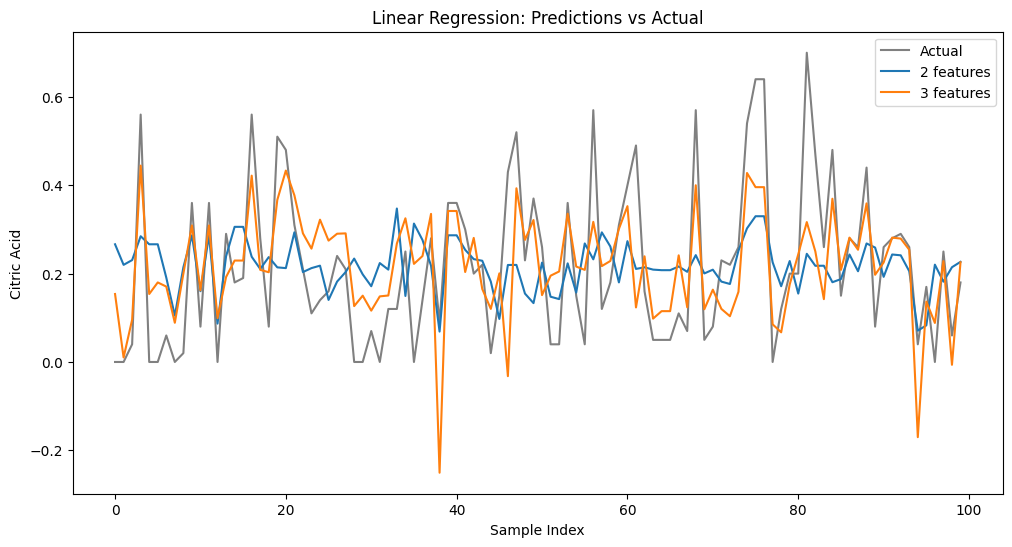

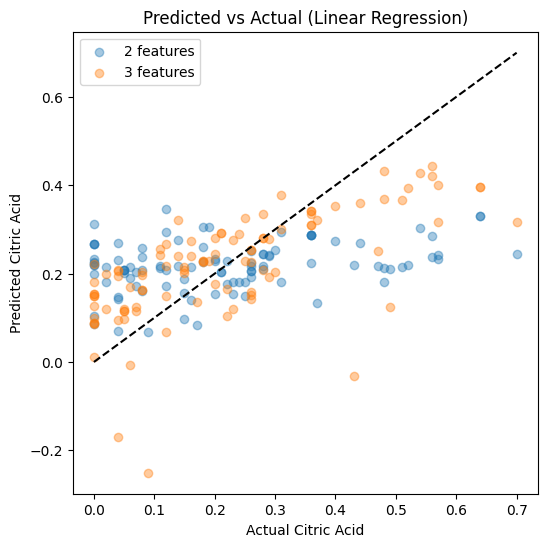

In [26]:
# TODO: Create comparison plots
# helper function to do the predicting

def predict(X, coefficients):
    n_samples = X.shape[0]
    X_bias = np.hstack((np.ones((n_samples, 1)), X))
    return X_bias @ coefficients
# predicting the model with 2 and 3 features 
y_pred_2 = predict(X_2features, model_2)
y_pred_3 = predict(X_3features, model_3)

# initial noisy plotting for comparison 
plt.figure(figsize=(12, 6))
plt.plot(y, label='Actual', color='gray')
plt.plot(y_pred_2, label='2 features')
plt.plot(y_pred_3, label='3 features')
plt.legend()
plt.xlabel('Sample Index')
plt.ylabel('Citric Acid')
plt.title('Linear Regression: Predictions vs Actual')
plt.show()

# slightly improved plot
plt.figure(figsize=(6, 6))

plt.scatter(y, y_pred_2, alpha=0.4, label='2 features')
plt.scatter(y, y_pred_3, alpha=0.4, label='3 features')

# Perfect prediction line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--')

plt.xlabel('Actual Citric Acid')
plt.ylabel('Predicted Citric Acid')
plt.legend()
plt.title('Predicted vs Actual (Linear Regression)')
plt.show()


# Discussion 

For the second plot, a scatter plot can better be used to see how accurate the predictions are. If the predictions align with the actual results, they should lie on the line y=x. As seen, the orange points, that represent the model with three features appear to be closer to that linear regression line than the points using the two feature model. This suggests a better overall performent of the two feature mode.

## Summary and Discussion

### Results Table
| Model | Features | Error |
|-------|----------|-------|
| Model 1 | alcohol, density | 0.1686 |
| Model 2 | alcohol, density, volatile_acidity | 0.13203983518141008 |
| Model 3 | alcohol, density, volatile_acidity, fixed_acidity | 0.12415866052191836|
| Full Model | all features | 0.1055 |

### Discussion
*Write your analysis here:*
- Which features are most important for predicting citric acid?
- Does adding more features always improve the model?
- What did you learn from this exercise?

The predicted versus actual scatter plot shows that the three-feature model produces predictions that lie closer to the ideal $y = x$ line than the two-feature model, indicating improved accuracy. This visual trend is consistent with the error values in Table 1, where adding volatile acidity reduces the RMSE from $0.1686$ to $0.1320$. Including fixed acidity as a fourth feature further lowers the error to $0.1242$, while using all features yields the lowest training error of $0.1055$.

Volatile acidity appears to be the most important additional feature for predicting citric acid, as it produces the largest reduction in error when added to the baseline model. Fixed acidity also contributes useful information, but with a smaller effect. Although adding more features continues to reduce the training error, the improvements diminish with each additional feature, suggesting feature redundancy and the potential for overfitting.

This exercise demonstrates the importance of careful feature selection and the value of combining numerical metrics with visualization. A small set of informative features can significantly improve performance, while additional features may provide only marginal gains.

